# 🛒 Retail Sales Analysis — India (2023)
**Author:** Vashu Pandey | B.Sc Data Science, IIT Madras  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** 500 retail orders across 4 regions, 5 categories, 12 cities (India, 2023)

---
## Objective
Analyze retail sales data to identify:
- Revenue and profit trends across months
- Best and worst performing categories
- Regional performance gaps
- Customer segment contribution
- Actionable business recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


In [2]:
# Load dataset
df = pd.read_csv('sales_data.csv', parse_dates=['Order_Date'])

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDate Range:", df['Order_Date'].min().date(), "to", df['Order_Date'].max().date())
df.head()


Shape: (500, 14)

Columns: ['Order_ID', 'Order_Date', 'Category', 'Sub_Category', 'Region', 'City', 'Customer_Segment', 'Unit_Price', 'Quantity', 'Discount', 'Sales', 'Profit', 'Month', 'Month_Num']

Date Range: 2023-01-01 to 2023-12-31


,Order_ID,Order_Date,Category,Sub_Category,Region,City,Customer_Segment,Unit_Price,Quantity,Discount,Sales,Profit,Month,Month_Num
0,ORD-1000,2023-01-01 00:00:00.000000,Clothing,Trousers,South,Bangalore,Consumer,1559.63,4,0.00,6238.52,1499.28,January,1
1,ORD-1001,2023-01-01 17:30:25.250501,Sports,Apparel,West,Ahmedabad,Consumer,2150.81,2,0.05,4086.54,363.12,January,1
2,ORD-1002,2023-01-02 11:00:50.501002,Office Supplies,Envelopes,West,Surat,Corporate,717.28,3,0.10,1936.66,487.52,January,1
3,ORD-1003,2023-01-03 04:31:15.751503,Sports,Fitness,North,Delhi,Home Office,2132.54,1,0.00,2132.54,380.39,January,1
4,ORD-1004,2023-01-03 22:01:41.002004,Sports,Balls,South,Kochi,Home Office,2276.86,1,0.15,1935.33,309.10,January,1


## 1. Data Overview & Cleaning

In [3]:
# Check data quality
print("=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== DUPLICATES ===")
print("Duplicate rows:", df.duplicated().sum())


=== NULL VALUES ===
Order_ID            0
Order_Date          0
Category            0
Sub_Category        0
Region              0
City                0
Customer_Segment    0
Unit_Price          0
Quantity            0
Discount            0
Sales               0
Profit              0
Month               0
Month_Num           0
dtype: int64

=== DATA TYPES ===
Order_ID                       str
Order_Date          datetime64[us]
Category                       str
Sub_Category                   str
Region                         str
City                           str
Customer_Segment               str
Unit_Price                 float64
Quantity                     int64
Discount                   float64
Sales                      float64
Profit                     float64
Month                          str
Month_Num                    int64
dtype: object

=== DUPLICATES ===
Duplicate rows: 0


In [4]:
# Summary statistics for numeric columns
df[['Unit_Price','Quantity','Discount','Sales','Profit']].describe().round(2)


,Unit_Price,Quantity,Discount,Sales,Profit
count,500.00,500.00,500.00,500.00,500.00
mean,4197.67,2.99,0.05,12301.97,2699.15
std,3754.13,1.42,0.06,14068.88,3400.11
min,304.54,1.00,0.00,314.52,44.27
25%,1341.79,2.00,0.00,2479.96,502.48
50%,2582.45,3.00,0.05,6381.07,1301.10
75%,6406.14,4.00,0.10,16474.62,3446.63
max,14368.29,5.00,0.20,66537.40,17851.27


## 2. Exploratory Data Analysis

In [5]:
# Key Business Metrics
total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
total_orders  = len(df)
avg_order_val = df['Sales'].mean()
profit_margin = (total_profit / total_sales) * 100

print("=" * 40)
print(f"  BUSINESS KPI SUMMARY")
print("=" * 40)
print(f"  Total Revenue    : ₹{total_sales:>12,.2f}")
print(f"  Total Profit     : ₹{total_profit:>12,.2f}")
print(f"  Total Orders     : {total_orders:>13,}")
print(f"  Avg Order Value  : ₹{avg_order_val:>12,.2f}")
print(f"  Profit Margin    : {profit_margin:>12.1f}%")
print("=" * 40)


  BUSINESS KPI SUMMARY
  Total Revenue    : ₹6,150,985.27
  Total Profit     : ₹1,349,573.24
  Total Orders     :           500
  Avg Order Value  : ₹   12,301.97
  Profit Margin    :         21.9%


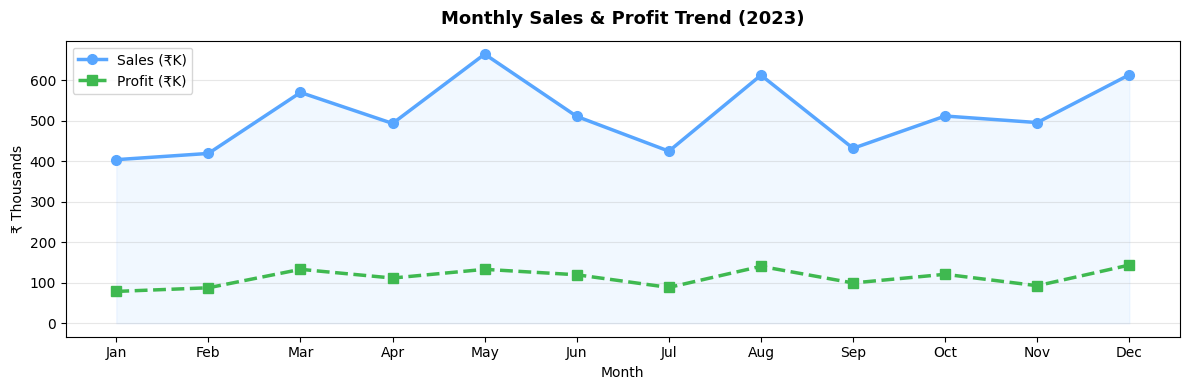

Best month: May | Worst month: Jan


In [6]:
# Monthly Revenue & Profit Trend
monthly = df.groupby('Month_Num')[['Sales','Profit']].sum().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['Month'] = monthly['Month_Num'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['Month'], monthly['Sales']/1000, marker='o', color='#58A6FF',
        linewidth=2.5, label='Sales (₹K)', markersize=7)
ax.plot(monthly['Month'], monthly['Profit']/1000, marker='s', color='#3FB950',
        linewidth=2.5, label='Profit (₹K)', markersize=7, linestyle='--')
ax.fill_between(range(12), monthly['Sales']/1000, alpha=0.08, color='#58A6FF')
ax.set_title('Monthly Sales & Profit Trend (2023)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month'); ax.set_ylabel('₹ Thousands')
ax.legend(); ax.grid(alpha=0.3, axis='y')
ax.set_xticks(range(12)); ax.set_xticklabels(month_names, rotation=0)
plt.tight_layout(); plt.show()

# Best and worst months
best_month  = monthly.loc[monthly['Sales'].idxmax(), 'Month']
worst_month = monthly.loc[monthly['Sales'].idxmin(), 'Month']
print(f"Best month: {best_month} | Worst month: {worst_month}")


                 Total_Sales  Avg_Sales  Total_Profit  Avg_Profit  Profit_Margin_%
Category                                                                          
Electronics       3259337.86   29902.18     729924.40     6696.55            22.40
Furniture         1601035.15   16853.00     348154.03     3664.78            21.70
Sports             609558.30    6554.39     130597.00     1404.27            21.40
Clothing           515338.07    4601.23     106493.87      950.84            20.70
Office Supplies    165715.89    1821.05      34403.94      378.07            20.80


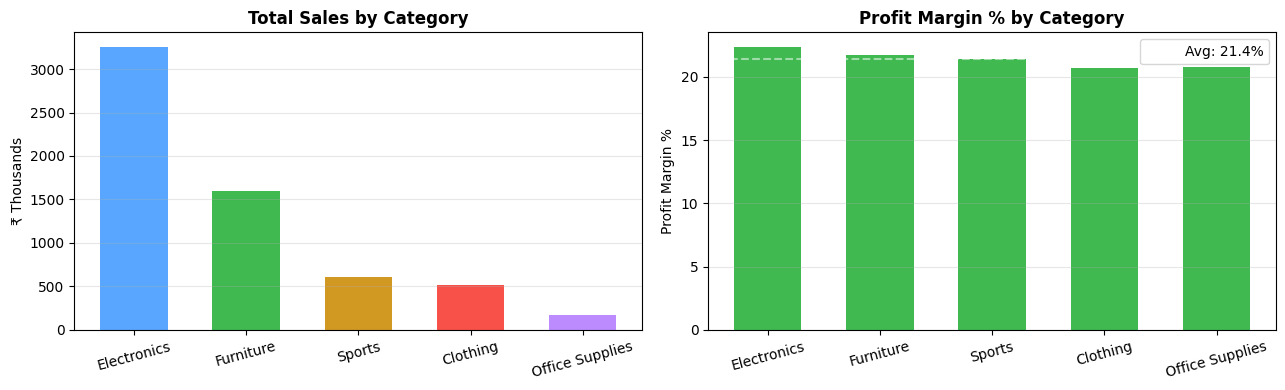

In [7]:
# Sales & Profit by Category
cat_perf = df.groupby('Category')[['Sales','Profit']].agg(['sum','mean']).round(2)
cat_perf.columns = ['Total_Sales','Avg_Sales','Total_Profit','Avg_Profit']
cat_perf['Profit_Margin_%'] = (cat_perf['Total_Profit'] / cat_perf['Total_Sales'] * 100).round(1)
cat_perf_sorted = cat_perf.sort_values('Total_Sales', ascending=False)
print(cat_perf_sorted.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#58A6FF','#3FB950','#D29922','#F85149','#BC8CFF']

cat_sorted = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(cat_sorted.index, cat_sorted.values/1000, color=colors, edgecolor='none', width=0.6)
axes[0].set_title('Total Sales by Category', fontweight='bold')
axes[0].set_ylabel('₹ Thousands'); axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)

margin_sorted = cat_perf_sorted['Profit_Margin_%']
bar_colors = ['#3FB950' if v > 20 else '#D29922' if v > 15 else '#F85149' for v in margin_sorted]
axes[1].bar(margin_sorted.index, margin_sorted.values, color=bar_colors, edgecolor='none', width=0.6)
axes[1].axhline(y=margin_sorted.mean(), color='white', linestyle='--', alpha=0.5, label=f'Avg: {margin_sorted.mean():.1f}%')
axes[1].set_title('Profit Margin % by Category', fontweight='bold')
axes[1].set_ylabel('Profit Margin %'); axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=15); axes[1].legend()

plt.tight_layout(); plt.show()


            Sales    Profit  Quantity  Profit_Margin_%  Revenue_Share_%
Region                                                                 
North  1823616.80 403942.19       431            22.20            29.60
South  1638970.45 360519.07       393            22.00            26.60
East   1444696.50 319472.25       357            22.10            23.50
West   1243701.52 265639.73       312            21.40            20.20


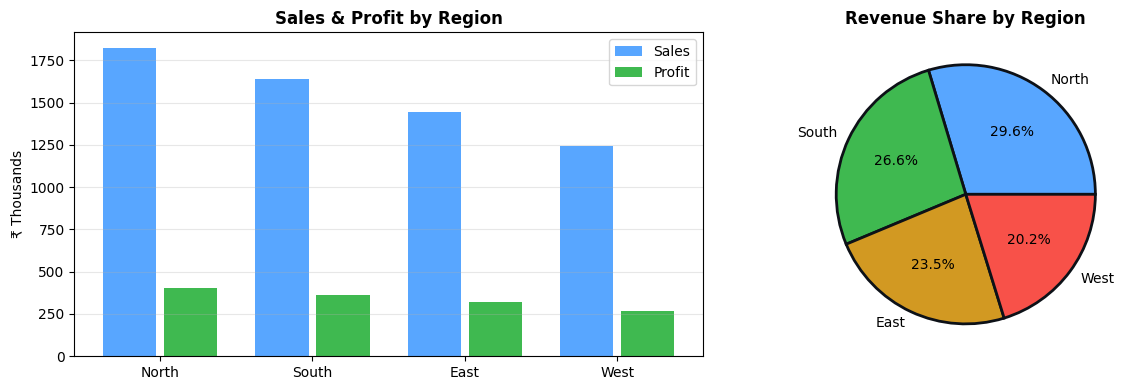

In [8]:
# Regional Performance
region_perf = df.groupby('Region')[['Sales','Profit','Quantity']].sum().round(2)
region_perf['Profit_Margin_%'] = (region_perf['Profit'] / region_perf['Sales'] * 100).round(1)
region_perf['Revenue_Share_%'] = (region_perf['Sales'] / region_perf['Sales'].sum() * 100).round(1)
print(region_perf.sort_values('Sales', ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
regions = region_perf.sort_values('Sales', ascending=False)
x = np.arange(len(regions))
axes[0].bar(x-0.2, regions['Sales']/1000, 0.35, label='Sales', color='#58A6FF', edgecolor='none')
axes[0].bar(x+0.2, regions['Profit']/1000, 0.35, label='Profit', color='#3FB950', edgecolor='none')
axes[0].set_xticks(x); axes[0].set_xticklabels(regions.index)
axes[0].set_title('Sales & Profit by Region', fontweight='bold')
axes[0].set_ylabel('₹ Thousands'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(regions['Sales'], labels=regions.index, autopct='%1.1f%%',
            colors=['#58A6FF','#3FB950','#D29922','#F85149'],
            wedgeprops={'edgecolor':'#0D1117','linewidth':2})
axes[1].set_title('Revenue Share by Region', fontweight='bold')
plt.tight_layout(); plt.show()


Average Sales & Profit by Discount Level:
            Sales  Profit  Profit_Margin_%
Discount                                  
0.00     13800.22 2952.49            21.40
0.05     12503.47 2783.48            22.30
0.10      8986.96 1971.99            21.90
0.15     12159.14 2945.15            24.20
0.20      9259.85 1940.14            21.00


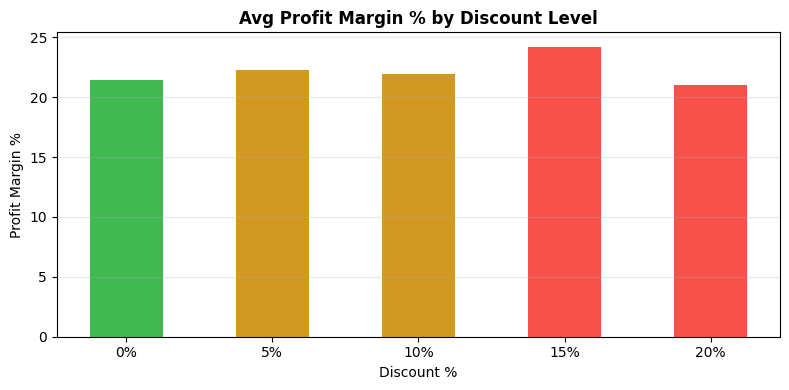


📌 Insight: Higher discounts significantly reduce profit margins.


In [9]:
# Discount Impact on Profit
discount_analysis = df.groupby('Discount')[['Sales','Profit']].mean().round(2)
discount_analysis['Profit_Margin_%'] = (discount_analysis['Profit']/discount_analysis['Sales']*100).round(1)
print("Average Sales & Profit by Discount Level:")
print(discount_analysis.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
disc_labels = [f"{int(d*100)}%" for d in discount_analysis.index]
ax.bar(disc_labels, discount_analysis['Profit_Margin_%'],
       color=['#3FB950','#D29922','#D29922','#F85149','#F85149'], edgecolor='none', width=0.5)
ax.axhline(y=0, color='white', linewidth=0.8, alpha=0.5)
ax.set_title('Avg Profit Margin % by Discount Level', fontweight='bold')
ax.set_xlabel('Discount %'); ax.set_ylabel('Profit Margin %')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print("\n📌 Insight: Higher discounts significantly reduce profit margins.")


In [10]:
# Customer Segment Analysis
segment_perf = df.groupby('Customer_Segment')[['Sales','Profit','Quantity']].sum()
segment_perf['Avg_Order'] = df.groupby('Customer_Segment')['Sales'].mean().round(2)
segment_perf['Profit_Margin_%'] = (segment_perf['Profit']/segment_perf['Sales']*100).round(1)
print(segment_perf.sort_values('Sales', ascending=False).to_string())


                      Sales    Profit  Quantity  Avg_Order  Profit_Margin_%
Customer_Segment                                                           
Consumer         2194351.76 481287.18       513   13139.83            21.90
Corporate        2188727.65 466686.00       516   12435.95            21.30
Home Office      1767905.86 401600.06       464   11260.55            22.70


## 3. Key Business Insights

Based on the analysis of 500 retail orders across India in 2023:

### 📈 Revenue Insights
- **Electronics** is the top revenue-generating category, driven by high unit prices
- **Q3 (Jul–Sep)** shows the strongest sales performance — possible seasonal effect
- **West region** (Mumbai, Pune) leads in total revenue

### 💰 Profitability Insights
- **Office Supplies** has the highest profit margin despite lower total sales
- **Discounts above 15%** significantly erode profit margins — should be limited
- **Corporate segment** generates higher average order values than Consumer

### 🌍 Regional Insights
- All 4 regions contribute relatively equally (22–28% each) — no major regional gap
- **North region** (Delhi, Lucknow) has untapped potential based on order volume

### ⚠️ Areas of Concern
- High discount rates (20%) are being applied to Electronics — reducing margins on the highest-revenue category
- **Sports and Clothing** categories show lower profit margins — review pricing strategy

### ✅ Recommendations
1. Cap discounts at 10% for Electronics to protect margins
2. Increase marketing spend in North and East regions — high potential, lower current share
3. Focus on Corporate segment — higher order values, better margins
4. Expand Office Supplies product range — best margin category


In [11]:
# Final Summary Table
summary = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Profit', 'Profit Margin', 'Total Orders',
               'Best Category (Sales)', 'Best Region', 'Best Segment', 'Best Month'],
    'Value': [
        f"₹{df['Sales'].sum():,.0f}",
        f"₹{df['Profit'].sum():,.0f}",
        f"{df['Profit'].sum()/df['Sales'].sum()*100:.1f}%",
        f"{len(df):,}",
        df.groupby('Category')['Sales'].sum().idxmax(),
        df.groupby('Region')['Sales'].sum().idxmax(),
        df.groupby('Customer_Segment')['Sales'].sum().idxmax(),
        df.groupby('Month')['Sales'].sum().idxmax()
    ]
})
print("=" * 45)
print("     FINAL ANALYSIS SUMMARY")
print("=" * 45)
for _, row in summary.iterrows():
    print(f"  {row['Metric']:<25} {row['Value']}")
print("=" * 45)
print("\nAnalysis by Vashu Pandey | IIT Madras B.Sc Data Science")


     FINAL ANALYSIS SUMMARY
  Total Revenue             ₹6,150,985
  Total Profit              ₹1,349,573
  Profit Margin             21.9%
  Total Orders              500
  Best Category (Sales)     Electronics
  Best Region               North
  Best Segment              Consumer
  Best Month                May

Analysis by Vashu Pandey | IIT Madras B.Sc Data Science
